# Filtered Facial Encoding Hamming Weight Experiments #

## Tunes the Angle of error tolerance to filter 'bad' hyperplanes ##

In [1]:
import face_recognition
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.stats import norm
import math
import os
import random
from scipy.special import betainc, betaincinv
import scipy.stats as stats 
from tqdm import tqdm
import pandas as pd
import json
from bsp import CosineLSH

### Now we define the image to encoding functionality for an particular image ###

# Section 0: Optimize Data #

In this section, we need to ensure there's no crazy data (filter) and put them in ram to ensure fast processing

1. We will build a dictionary data structure to support this
    - for each folder I will specify a max of faces and put them into the data structure (these will be the encoded version)

2. For future experiments I only need to consult this data structure

In [2]:
# Just in case we have additional dataset to test on
# folder_extracted="train_resnet50"
folder_extracted="train_resnet50"

# define the official data structure in RAM 

facial_data=dict()

### In order to save us time for future ##

We only need to do this once and we will store this Data into a json so I can later extract it

In [3]:
def restore(obj):
    if isinstance(obj, list):
        # If it's a list of numbers, convert to numpy array
        if all(isinstance(x, (int, float)) for x in obj):
            return np.array(obj)
        # Otherwise recurse element-wise
        return [restore(x) for x in obj]
    if isinstance(obj, dict):
        return {k: restore(v) for k, v in obj.items()}
    return obj

with open(f"data_{folder_extracted}.json", "r") as f:
    facial_data_loaded = json.load(f)

facial_data= restore(facial_data_loaded)

### Some Helper Functions ###

In [4]:
def mean_faces(encodings):
    # now to deal with for batch ==1
    if len(encodings)==1:
        return encodings[0]
    
    # Now deal with the regular batch
    arr = np.array(encodings, dtype=float)
    return arr.mean(axis=0)

def rand_subset(arr, k):
    if k > len(arr):
        raise ValueError("k cannot be larger than the length of arr")
    return random.sample(arr, k)

def rand_select(avoidance=None):
    if avoidance==None: 
        return random.randint(0,100)
    else:
        selected=random.randint(0,100)
        while selected==avoidance:
            selected=random.randint(0,100)
        return selected

# Section 1: Expected Size of IS #

In this section I want to calculate the expected value of the error set (IS)

In [10]:
hyperplane=32
dimension=128
degree_of_tolerance=[i for i in range(1,10)]

result_theory=[]
result_practice=[]

def expected_filtered_count(k, d, tolerance_degrees):
    """
    Calculates the expected number of hyperplanes filtered out.
    
    Args:
        k: Total number of hyperplanes
        d: Dimension of the vector space
        tolerance_degrees: The angle alpha (tolerance)
    """
    # Convert to radians
    alpha_rad = np.radians(tolerance_degrees)
    
    # Calculate x for the beta function: x = sin^2(alpha)
    x = np.sin(alpha_rad)**2
    
    # Parameters for the beta distribution
    a = 0.5
    b = (d - 1) / 2
    
    # Probability P(|dot| < threshold)
    probability = betainc(a, b, x)
    
    return k * probability

for degree in degree_of_tolerance:
    result_theory.append(expected_filtered_count(hyperplane,dimension,degree))

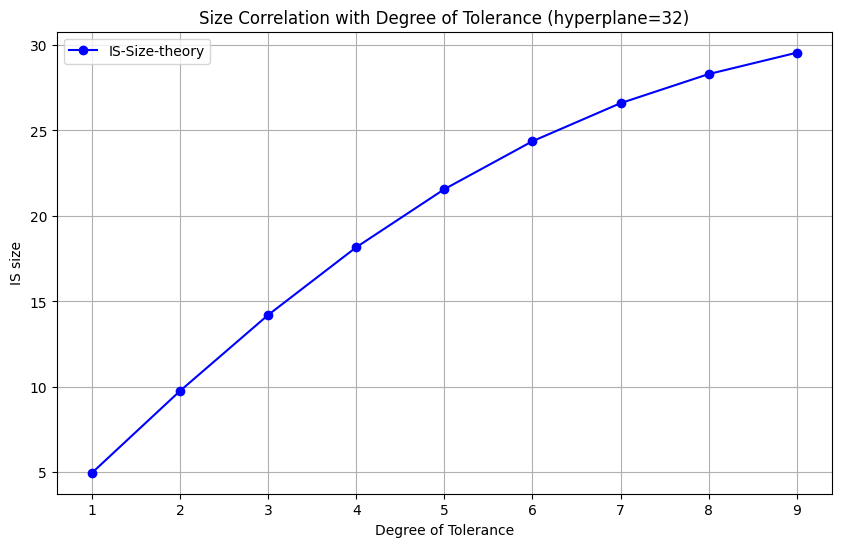

In [11]:
plt.figure(figsize=(10, 6))  # Optional: Set figure size (width, height)
plt.plot([each*1 for each in degree_of_tolerance], result_theory, marker='o', linestyle='-', color='b', label='IS-Size-theory')
# 3. Add labels
plt.title(f"Size Correlation with Degree of Tolerance (hyperplane={hyperplane})")
plt.xlabel("Degree of Tolerance")
plt.ylabel("IS size")
plt.grid(True)
plt.legend()

# 4. Show the plot
plt.show()

## Section 2.1: Test normalness among a single individual ##

We further test if face are normally distributed amount a single individual's mean and with std-deviation, I will define a helper function

In [8]:
import scipy.stats as stats

def test_angular_normality(faces_array):
    """
    Tests if the angles between faces and their centroid are normally distributed.
    
    Args:
        faces_array: (N, D) numpy array of facial embeddings.
    """
    # 1. Calculate Centroid
    centroid = np.mean(faces_array, axis=0)
    
    # 2. Normalize everything to unit length (Critical for Cosine/Angles)
    # Normalize centroid
    centroid = centroid / np.linalg.norm(centroid)
    
    # Normalize faces
    norms = np.linalg.norm(faces_array, axis=1, keepdims=True)
    faces_normalized = faces_array / norms
    
    # 3. Calculate Angles (in Degrees)
    # Dot product of normalized vectors = Cosine Similarity
    # Clip to [-1, 1] to avoid numerical errors with arccos
    cosines = np.dot(faces_normalized, centroid)
    cosines = np.clip(cosines, -1.0, 1.0)
    
    angles_deg = np.degrees(np.arccos(cosines))
    
    # 4. Statistical Tests
    print(f"--- Normality Test Report (N={len(angles_deg)}) ---")
    print(f"Mean Angle: {np.mean(angles_deg):.4f}°")
    print(f"Std Dev:    {np.std(angles_deg):.4f}°")
    
    # Shapiro-Wilk Test (Good for N < 5000)
    # Null Hypothesis: Data IS normally distributed.
    # If p-value < 0.05, we REJECT the null (It is NOT normal).
    shapiro_stat, shapiro_p = stats.shapiro(angles_deg)
    
    print("-" * 40)
    print(f"Shapiro-Wilk Test:")
    print(f"  Statistic: {shapiro_stat:.4f}")
    print(f"  p-value:   {shapiro_p:.4e}")
    
    if shapiro_p > 0.001:
        print("  RESULT: likely Normal (Gaussian).")
    else:
        print("  RESULT: NOT Normal (Deviates significantly).")

    # 5. Visual Check (Histogram + Q-Q Plot) 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram
    ax1.hist(angles_deg, bins=30, density=True, alpha=0.6, color='b', label='Observed')
    # ax1.hist(cosines, bins=30, density=True, alpha=0.6, color='b', label='Observed')
    
    # Overlay the ideal Normal Curve
    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(angles_deg), np.std(angles_deg))
    ax1.plot(x, p, 'k', linewidth=2, label='Ideal Normal')
    ax1.set_title('Histogram of Angles')
    ax1.set_xlabel('Angle (Degrees)')
    ax1.legend()
    
    # Q-Q Plot (Quantile-Quantile)
    # Points should lie on the red line if Normal
    stats.probplot(angles_deg, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()
    
    return angles_deg

--- Normality Test Report (N=569) ---
Mean Angle: 40.9245°
Std Dev:    9.8287°
----------------------------------------
Shapiro-Wilk Test:
  Statistic: 0.8600
  p-value:   4.1573e-22
  RESULT: NOT Normal (Deviates significantly).


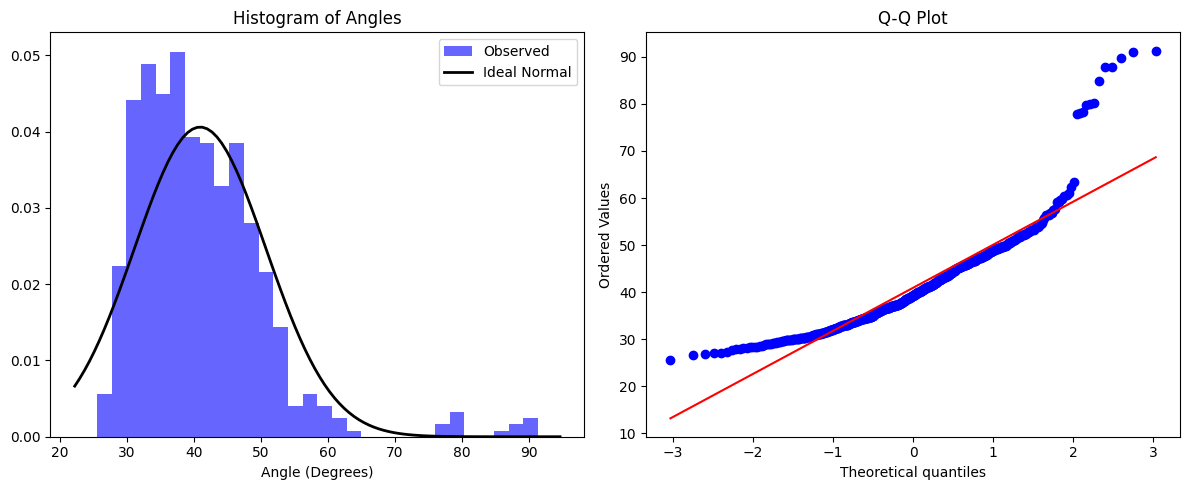

array([30.564773  , 33.07754475, 28.41857629, 31.22291369, 29.73170713,
       30.30248896, 34.37580653, 29.00249074, 29.87410526, 32.73569515,
       29.55284214, 31.12640403, 27.07882257, 30.55510249, 29.95636301,
       29.34695978, 30.61516423, 32.95937468, 33.03620573, 33.01070121,
       26.77749883, 34.48649744, 30.48610491, 28.04376651, 36.56594847,
       32.03953541, 29.13397939, 32.02557206, 34.20498312, 28.44049471,
       31.56973317, 29.23836953, 29.91635318, 29.89056765, 31.0882887 ,
       38.69873679, 29.02163309, 26.70533967, 32.22845197, 29.38703082,
       32.72842386, 34.80896914, 32.69358766, 33.49979951, 28.3233233 ,
       27.15284212, 33.12701853, 30.27359774, 31.24227044, 34.46762911,
       31.54900312, 28.98149507, 31.66232656, 30.8545323 , 27.29699578,
       38.550923  , 28.48796522, 34.21840355, 25.50731733, 37.32168584,
       43.48938599, 28.8685912 , 32.82119277, 30.28987648, 28.5142024 ,
       35.50928336, 33.77746767, 34.2533853 , 30.35180133, 32.47

In [11]:
# select a random folder of a single person and run the test

faces=facial_data[list(facial_data.keys())[rand_select()]]
test_angular_normality(faces)

# Section 3： Crossover point(s) for false positive and false negative with bagging mechanism #

1. In this section I will show how the bagging cause the false positive and false negative to change 
2. I also show the theory result 

### Now Define the testing routine function first ###

NOTE: this is only for a single person (randomly chosen)

In [5]:
def testing_single_person_bag(hyperplane, bag_number, probablistic=False, k_bits=None, hmwT=0):
    """
    Tests a single random person's FP/FN rates using:
    1. Hashed Bagging (averaged over 30 random initializations)
    2. Regular Angular Distance (mapped to equivalent filtered count)
    
    Now supports k_bits to simulate quantized integer vectors, 
    and hmwT for Hamming Weight Tolerance.
    """
    
    # 1. Setup Data & Template
    person_ids = list(facial_data.keys())
    selected_idx = rand_select() 
    selected_id = person_ids[selected_idx]
    
    template = mean_faces(facial_data[selected_id])

    # ---------------------------------------------------------
    # PART A: CipherSpace Testing (Hashed + Bagging)
    # ---------------------------------------------------------
    
    IS_set_hashed = list(range(math.floor(hyperplane*0.5)))
    
    accumulated_fp = np.zeros(len(IS_set_hashed))
    accumulated_fn = np.zeros(len(IS_set_hashed))
    
    iterations = 5
    
    for _ in range(iterations):
        hashing_bags = [CosineLSH(hyperplane, 512) for _ in range(bag_number)]
        template_strings = [h.hash(template, k_bits=k_bits) for h in hashing_bags]

        for idx, num_discard in enumerate(IS_set_hashed):
            
            for h in hashing_bags:
                h.filter_by_hyperplane(template, num_discard, k_bits=k_bits)
            
            distance_fp = []
            distance_fn = []

            for _ in range(100):
                other_idx = rand_select(selected_idx) 
                other_id = person_ids[other_idx]
                fp_vecs = rand_subset(facial_data[other_id], 2)
                fp_str_vec = mean_faces(fp_vecs)
                
                fn_vecs = rand_subset(facial_data[selected_id], 2)
                fn_str_vec = mean_faces(fn_vecs)

                string_fps = [h.hash(fp_str_vec, k_bits=k_bits) for h in hashing_bags]
                string_fns = [h.hash(fn_str_vec, k_bits=k_bits) for h in hashing_bags]

                # NEW: Pass hmwT down to the distance check
                d_fp = min([hashing_bags[b].filtered_hamming_weights(template_strings[b], string_fps[b], hmwT=hmwT) 
                            for b in range(bag_number)])
                d_fn = min([hashing_bags[b].filtered_hamming_weights(template_strings[b], string_fns[b], hmwT=hmwT) 
                            for b in range(bag_number)])
                
                distance_fp.append(d_fp)
                distance_fn.append(d_fn)

            curr_fp_rate = distance_fp.count(0) / len(distance_fp)
            curr_fn_rate = (len(distance_fn) - distance_fn.count(0)) / len(distance_fn)
            
            accumulated_fp[idx] += curr_fp_rate
            accumulated_fn[idx] += curr_fn_rate

    fp_hashed = (accumulated_fp / iterations).tolist()
    fn_hashed = (accumulated_fn / iterations).tolist()

    return fp_hashed, fn_hashed, IS_set_hashed


def run_multi_person_hyperplane_experiment(hyperplane, bag_number, num_people=30, probablistic=False, k_bits=None, hmwT=0):
    """
    Runs the 'testing_single_person_bag' experiment multiple times 
    and returns the AVERAGED FP/FN curves.
    
    Now explicitly accepts k_bits to test quantization impacts,
    and hmwT to test expanded error bubbles.
    """
    
    total_fp_hash = None
    total_fn_hash = None
    
    x_axis_values = None
    
    for _ in tqdm(range(num_people), desc=f"Testing {num_people} People (k={k_bits if k_bits else 'Float'}, hmwT={hmwT})"):
        res = testing_single_person_bag(
            hyperplane=hyperplane, 
            bag_number=bag_number,
            probablistic=probablistic,
            k_bits=k_bits,
            hmwT=hmwT # Pass it down here!
        )
        
        fp_h, fn_h, x_axis_ref = res
        
        if total_fp_hash is None:
            total_fp_hash = np.zeros_like(fp_h, dtype=float)
            total_fn_hash = np.zeros_like(fn_h, dtype=float)
            x_axis_values = x_axis_ref 
        
        total_fp_hash += np.array(fp_h)
        total_fn_hash += np.array(fn_h)
        
    avg_fp_hash = total_fp_hash / num_people
    avg_fn_hash = total_fn_hash / num_people
    
    return avg_fp_hash, avg_fn_hash, x_axis_values

In [6]:
def angular_distance(v1, v2):
    """Calculates the angular distance in degrees between two vectors."""
    v1_u = v1 / np.linalg.norm(v1)
    v2_u = v2 / np.linalg.norm(v2)
    dot = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
    return np.degrees(np.arccos(dot))

def evaluate_fn_rate(facial_dataset, num_people=30, thresholds=np.arange(5, 51)):
    """
    Evaluates the False Negative (FN) rate.
    FN = A legitimate user is REJECTED because their distance > threshold.
    """
    person_ids = list(facial_dataset.keys())
    total_fn_rates = np.zeros(len(thresholds))
    
    # Randomly select 'num_people' to average over
    selected_people = random.sample(person_ids, min(num_people, len(person_ids)))
    
    for person in tqdm(selected_people, desc="Evaluating FN Rate"):
        faces = facial_dataset[person]
        
        # 1. Average all faces to create the base template
        base_template = np.mean(faces, axis=0)
        
        # 2. Iterate through all the person's faces and calculate angular distance
        distances = np.array([angular_distance(face, base_template) for face in faces])
        
        # 3. Calculate FN rate for each threshold
        # (Rejected if their distance is strictly greater than the threshold)
        fn_rates = np.array([np.sum(distances > t) / len(distances) for t in thresholds])
        
        total_fn_rates += fn_rates
        
    # Average the FN rates across all selected people
    avg_fn_rates = total_fn_rates / len(selected_people)
    return thresholds, avg_fn_rates

def evaluate_fp_rate(facial_dataset, num_people=30, faces_per_other=10, thresholds=np.arange(5, 51)):
    """
    Evaluates the False Positive (FP) rate.
    FP = An imposter is ACCEPTED because their distance <= threshold.
    """
    person_ids = list(facial_dataset.keys())
    total_fp_rates = np.zeros(len(thresholds))
    
    selected_people = random.sample(person_ids, min(num_people, len(person_ids)))
    
    for person in tqdm(selected_people, desc="Evaluating FP Rate"):
        faces = facial_dataset[person]
        
        # 1. Average all faces to create the base template
        base_template = np.mean(faces, axis=0)
        
        distances = []
        
        # 2. Iterate through all OTHER people
        for other_person in person_ids:
            if other_person == person:
                continue  # Skip the legitimate user
                
            other_faces = facial_dataset[other_person]
            
            # Pick up to 10 random faces from the other person
            sample_size = min(faces_per_other, len(other_faces))
            sampled_faces = random.sample(other_faces, sample_size)
            
            # Calculate angular distances for these imposters
            distances.extend([angular_distance(face, base_template) for face in sampled_faces])
            
        distances = np.array(distances)
        
        # 3. Calculate FP rate for each threshold
        # (Accepted if their distance is less than or equal to the threshold)
        if len(distances) > 0:
            fp_rates = np.array([np.sum(distances <= t) / len(distances) for t in thresholds])
            total_fp_rates += fp_rates
            
    # Average the FP rates across all selected people
    avg_fp_rates = total_fp_rates / len(selected_people)
    return thresholds, avg_fp_rates

In [7]:
def find_crossover(x_axis, fp_rates, fn_rates):
    """
    Finds the intersection point (x, y) where FP matches FN.
    Uses linear interpolation for precision between discrete points.
    """
    x_axis = np.array(x_axis)
    fp_rates = np.array(fp_rates)
    fn_rates = np.array(fn_rates)
    
    # Calculate difference
    diff = fp_rates - fn_rates
    
    # Find indices where sign changes (FP crosses FN)
    # usually FN starts high and FP starts low, so diff starts negative and goes positive
    # We look for where diff > 0
    cross_indices = np.where(np.diff(np.sign(diff)))[0]
    
    if len(cross_indices) == 0:
        return None, None # No intersection found
    
    # Take the first crossing
    idx = cross_indices[0]
    
    # --- Linear Interpolation ---
    # We have two points: (x1, d1) and (x2, d2)
    # We want to find x where d = 0
    
    x1, x2 = x_axis[idx], x_axis[idx+1]
    y_fp1, y_fp2 = fp_rates[idx], fp_rates[idx+1]
    y_fn1, y_fn2 = fn_rates[idx], fn_rates[idx+1]
    
    # Difference at points
    d1 = y_fp1 - y_fn1
    d2 = y_fp2 - y_fn2
    
    # Fraction of distance from x1 to x2
    # If d1 is -0.1 and d2 is 0.1, we are exactly in the middle (0.5)
    fraction = abs(d1) / (abs(d1) + abs(d2))
    
    x_cross = x1 + fraction * (x2 - x1)
    
    # Interpolate the Y value (Rate) at that X
    # We can use either FP or FN slope, they should meet at the same Y
    y_cross = y_fp1 + fraction * (y_fp2 - y_fp1)
    
    return x_cross, y_cross

## Section ??: Convergence ##

Note that the theory and the experiment does not match: WHY 

They actually converge eventually, but this requires the number of hyperplanes "fill" the whole hyper-ball

In [ ]:
def run_convergence_experiment(bag_number=1, batch_size=1):
    def vector_angle(v1, v2):
        v1_u = v1 / np.linalg.norm(v1)
        v2_u = v2 / np.linalg.norm(v2)
        dot = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
        return np.degrees(np.arccos(dot))
    
    # We will test these sizes. 
    # Warning: N=4096 might take a minute to run!
    N_values = [64, 512, 4096] 
    
    plt.figure(figsize=(12, 7))
    
    # 1. Plot the Single Theoretical Curve (It is Scale-Invariant)
    # We calculate this once using high precision
    theory_fraction = np.linspace(0, 1.0, 100)
    theory_fn = []
    
    # Re-using your theory logic to generate the baseline
    def get_degree_from_fraction(f, dim=128):
        if f >= 1.0: return 90.0
        if f <= 0.0: return 0.0
        # Inverse Beta to get alpha
        sin_sq = betaincinv(0.5, (dim - 1) / 2.0, f)
        return np.degrees(np.arcsin(np.sqrt(sin_sq)))

    # Use a fixed person for consistency
    selected_idx = rand_select()
    person_id = list(facial_data.keys())[selected_idx]
    template = mean_faces(rand_subset(facial_data[person_id], batch_size))
    
    # Generate Theory Curve
    print("Generating Theoretical Baseline...")
    for f in theory_fraction:
        alpha = get_degree_from_fraction(f)
        
        # Monte Carlo Integration for Theory (Fast)
        # We simulate the PROBABILITY formula we derived
        prob_fn_sum = 0
        mc_runs = 500
        for _ in range(mc_runs):
            # Same person comparison
            fn_vec = mean_faces(rand_subset(facial_data[person_id], batch_size))
            theta = vector_angle(fn_vec, template)
            
            # Probability Logic
            if theta <= 2 * alpha:
                p_single = 1.0
            else:
                p_single = max(0.0, 1.0 - (theta - 2 * alpha) / 180.0)
            
            # If we assume infinite N, k_survivors is proportional to (1-f)
            # But the exponent depends on N. 
            # Actually, the Rate (FN) depends on N. 
            # To compare effectively, we must fix the "Power" of the test.
            # Let's plot the "Single Bit Failure Rate" to be scale invariant?
            # No, let's just plot the N=4096 Theory.
            pass
    
    # --- SIMPLIFIED APPROACH: Just Run the Experiments ---
    # We will plot N=64 vs N=4096. 
    # If the hypothesis is true, N=4096 will look "worse" (closer to theory) than N=64.
    
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for i, N in enumerate(N_values):
        print(f"Running Experiment for N={N}...")
        
        # Initialize LSH
        hashing = CosineLSH(N, 128)
        template_hash = hashing.hash(template)
        
        # X-Axis: Fraction of planes discarded (0.0 to 1.0)
        # We pick 50 points along the x-axis
        discard_counts = np.linspace(0, N, 50, dtype=int)
        fractions = discard_counts / N
        
        fn_rates = []
        
        for k in discard_counts:
            # 1. Filter the TOP K bad planes
            # (We use the Smart Filtering function)
            hashing.filter_by_hyperplane(template, k)
            
            # 2. Measure FN Rate
            misses = 0
            total = 200
            
            for _ in range(total):
                # Same person sample
                target = mean_faces(rand_subset(facial_data[person_id], batch_size))
                target_hash = hashing.hash(target)
                
                # Check match (Hamming Distance)
                # Note: filter_by_hyperplane sets the mask internally
                dist = hashing.filtered_hamming_weights(template_hash, target_hash)
                
                # In Bagging=1, distance > 0 is a miss
                if dist > 0:
                    misses += 1
            
            fn_rates.append(misses / total)
            
        plt.plot(fractions, fn_rates, 
                 marker='o', markersize=3, label=f'Experiment N={N}', color=colors[i])

    # Plot the Theoretical Curve for the LARGEST N (Asymptote)
    # We compute this specifically for the largest N to show convergence
    theory_curve = []
    print(f"Calculating Theory for N={N_values[-1]}...")
    for f in np.linspace(0, 1.0, 50):
        alpha = get_degree_from_fraction(f)
        k_surv = int(N_values[-1] * (1 - f))
        
        sum_prob = 0
        for _ in range(500):
            fn_vec = mean_faces(rand_subset(facial_data[person_id], batch_size))
            theta = vector_angle(fn_vec, template)
            
            if theta <= 2*alpha: p_bit = 1.0
            else: p_bit = max(0.0, 1.0 - (theta - 2*alpha)/180.0)
            
            if k_surv == 0: p_match = 1.0
            else: p_match = p_bit ** k_surv
            
            sum_prob += (1.0 - p_match)
            
        theory_curve.append(sum_prob / 500)

    plt.plot(np.linspace(0, 1.0, 50), theory_curve, 
             label=f'Theory (N={N_values[-1]})', color='red', linestyle='--', linewidth=2)

    plt.title('Convergence to Theory: Finite Sample Advantage (N=64) vs Law of Large Numbers')
    plt.xlabel('Fraction of Hyperplanes Discarded')
    plt.ylabel('False Negative Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run it
run_convergence_experiment()

## Another Way to Look At the Bagging, Change the number of bags and see the effects ##

In [9]:
import pandas as pd

def generate_comprehensive_csv_results():
    # 1. Define the parameter grid you want to explore
    M_values = [40,50]               # Number of Hyperplanes (M)
    D_values = [100,150]           # Number of Bags (D)
    num_people_to_test = 30          # Number of random users to average
    k_bits_val = None                # Quantization level (or None for Float)
    
    results = []
    
    # Clean filename handling (outputs "Float" instead of "Nonebit")
    bit_label = f"{k_bits_val}bit" if k_bits_val is not None else "Float"
    csv_filename = f"LSH_Grid_Results_{bit_label}.csv"

    # 2. Iterate through M and D
    for M in M_values:
        for D in D_values:
            print(f"Running Experiment: M={M}, Bags={D}")
            
            # Run your existing experiment function
            avg_fp_hash, avg_fn_hash, T_values = run_multi_person_hyperplane_experiment(
                hyperplane=M,
                bag_number=D,
                num_people=num_people_to_test,
                probablistic=True,  
                k_bits=k_bits_val,
                hmwT=2
            )
            
            # 3. Unpack the arrays and map them to their specific T (Filtered) value
            for idx, T in enumerate(T_values):
                results.append({
                    'M (Hyperplanes)': M,
                    'D (Bags)': D,
                    'T (Filtered)': T,
                    'FP (Hashed)': avg_fp_hash[idx],
                    'FN (Hashed)': avg_fn_hash[idx]
                })

        # 4. CHECKPOINT: Save to CSV immediately after finishing all bags for this M
        df_results = pd.DataFrame(results)
        df_results.to_csv(csv_filename, index=False)
        print(f"--> [Checkpoint] Progress safely written to '{csv_filename}' after completing M={M}")

    print(f"\nSuccess! Full parameter grid completed and saved to '{csv_filename}'")


generate_comprehensive_csv_results()

Running Experiment: M=40, Bags=100


Testing 30 People (k=Float, hmwT=2):   7%|▋         | 2/30 [06:00<1:23:18, 178.52s/it]

### Test on quantization ###

In [7]:
def generate_vector_pair_at_angle(dim=512, min_angle=10, max_angle=40):
    """Generates a pair of 512-D unit vectors with a uniformly random angle."""
    theta_rad = np.radians(np.random.uniform(min_angle, max_angle))
    
    u = np.random.randn(dim)
    u /= np.linalg.norm(u)
    
    v_temp = np.random.randn(dim)
    w = v_temp - np.dot(v_temp, u) * u  
    w /= np.linalg.norm(w)              
    
    v = u * np.cos(theta_rad) + w * np.sin(theta_rad)
    return u, v

def quantize_absmax(vector, bit_depth):
    """Applies dynamic Max-Absolute Scaling."""
    x_max = np.max(np.abs(vector))
    max_int = (2 ** (bit_depth - 1)) - 1
    return np.round((vector / x_max) * max_int)

def run_cosine_fidelity_experiment():
    # Using 10,000 pairs to get highly stable "Max" outlier values
    num_pairs = 10000 
    dimensions = 512
    bit_depths = [i for i in range(5,21)]
    
    results = []
    print(f"Running quantization experiment on {num_pairs} pairs in {dimensions}-D space...\n")

    for i in range(num_pairs):
        u, v = generate_vector_pair_at_angle(dimensions, 10, 40)
        true_cosine = np.dot(u, v) 
        
        for bits in bit_depths:
            q_u = quantize_absmax(u, bits)
            q_v = quantize_absmax(v, bits)
            
            # Calculate Quantized Cosine Similarity
            q_norm_u = np.linalg.norm(q_u)
            q_norm_v = np.linalg.norm(q_v)
            
            if q_norm_u == 0 or q_norm_v == 0:
                q_cosine = 0
            else:
                q_cosine = np.dot(q_u, q_v) / (q_norm_u * q_norm_v)
            
            # 1. Absolute Delta Cosine
            delta_cosine = abs(true_cosine - q_cosine)
            
            # 2. Relative Percentage Change
            # Formula: (Delta / True) * 100
            percent_change = (delta_cosine / abs(true_cosine)) * 100
            
            results.append({
                'Bits': bits,
                'Delta_Cosine': delta_cosine,
                'Percent_Change': percent_change
            })

    # Compile into a DataFrame
    df = pd.DataFrame(results)
    
    # Aggregate to match the exact table headers
    summary = df.groupby('Bits').agg(
        Mean_Delta_Cosine=('Delta_Cosine', 'mean'),
        Max_Delta_Cosine=('Delta_Cosine', 'max'),
        Mean_Percent_Change=('Percent_Change', 'mean'),
        Max_Percent_Change=('Percent_Change', 'max')
    ).reset_index()
    
    # Sort descending by bit depth
    summary = summary.sort_values('Bits', ascending=False)
    summary.to_csv('quantization_data.csv', index=False)
    
    # Format the output to identically match your LaTeX table image
    print(f"{'Bits':<6} | {'Mean (Δ Cosine)':<18} | {'Max (Δ Cosine)':<18} | {'Mean (%)':<20} | {'Max (%)':<10}")
    print("-" * 80)
    
    for _, row in summary.iterrows():
        print(f"{int(row['Bits']):<6} | "
              f"{row['Mean_Delta_Cosine']:.7f}          | "
              f"{row['Max_Delta_Cosine']:.7f}          | "
              f"{row['Mean_Percent_Change']:.4f}%              | "
              f"{row['Max_Percent_Change']:.4f}%")


run_cosine_fidelity_experiment()

Running quantization experiment on 10000 pairs in 512-D space...

Bits   | Mean (Δ Cosine)    | Max (Δ Cosine)     | Mean (%)             | Max (%)   
--------------------------------------------------------------------------------
20     | 0.0000000          | 0.0000002          | 0.0000%              | 0.0000%
19     | 0.0000001          | 0.0000005          | 0.0000%              | 0.0001%
18     | 0.0000001          | 0.0000010          | 0.0000%              | 0.0001%
17     | 0.0000003          | 0.0000017          | 0.0000%              | 0.0002%
16     | 0.0000006          | 0.0000043          | 0.0001%              | 0.0006%
15     | 0.0000012          | 0.0000095          | 0.0001%              | 0.0011%
14     | 0.0000024          | 0.0000167          | 0.0003%              | 0.0022%
13     | 0.0000048          | 0.0000314          | 0.0005%              | 0.0039%
12     | 0.0000098          | 0.0000785          | 0.0011%              | 0.0091%
11     | 0.0000189          | 